#                                              NLP ASSIGNMENT

1.  Install required libraries

In [ ]:
# Install required libraries
!pip install -q transformers datasets accelerate
!pip install -q shap lime
!pip install -q matplotlib seaborn scikit-learn

# Check GPU
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
GPU Available: True
Device: cuda


2.Load Dataset

In [ ]:
from datasets import load_dataset

# Load full dataset
dataset = load_dataset("fancyzhx/amazon_polarity")

# Dataset structure
print(dataset)

# Sizes
print("Train size:", len(dataset["train"]))
print("Test size:", len(dataset["test"]))

# Show sample
print(dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})
Train size: 3600000
Test size: 400000
{'label': 1, 'title': 'Stuning even for the non-gamer', 'content': 'This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'}


3.Text Preprocessing

In [ ]:
def preprocess(example):
    # Combine title and content
    text = example["title"] + " " + example["content"]

    # Basic cleaning
    text = text.lower().strip()

    return {"text": text, "label": example["label"]}

# Apply preprocessing
dataset = dataset.map(preprocess)

# Remove unused columns
dataset = dataset.remove_columns(["title", "content"])

# Check result
print(dataset)
print(dataset["train"][0])

Map:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 400000
    })
})
{'label': 1, 'text': 'stuning even for the non-gamer this sound track was beautiful! it paints the senery in your mind so well i would recomend it even to people who hate vid. game music! i have played the game chrono cross but out of all of the games i have ever played it has the best music! it backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. it would impress anyone who cares to listen! ^_^'}


4.BERT Tokenization

In [ ]:
from transformers import AutoTokenizer

# Load BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenization function
def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Apply tokenization
tokenized_dataset = dataset.map(tokenize, batched=True)

# Remove text column (keep only tensors)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

# Set format for PyTorch
tokenized_dataset.set_format("torch")

# Check output
print(tokenized_dataset)
print(tokenized_dataset["train"][0])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 400000
    })
})
{'label': tensor(1), 'input_ids': tensor([  101, 24646,  5582,  2130,  2005,  1996,  2512,  1011, 27911,  2023,
         2614,  2650,  2001,  3376,   999,  2009, 23262,  1996, 12411,  7301,
         1999,  2115,  2568,  2061,  2092,  1045,  2052, 28667,  8462,  4859,
         2009,  2130,  2000,  2111,  2040,  5223,  6819,  2094,  1012,  2208,
         2189,   999,  1045,  2031,  2209,  1996,  2208, 10381,  4948,  2080,
         2892,  2021,  2041,  1997,  2035,  1997,  1996,  2399,  1045,  2031,
         2412,  2209,  2009,  2038,  1996,  2190,  2189,   999,  2009, 10457,
         2185,  2013, 13587,  9019,  2075,  1998,  3138,  1037,  4840,  2121,
         3357,  2007, 24665,  3686,  7334,  1998,  3969,  3993,

5.Train/Validation Split + Small Efficient Training Setup

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
# =========================================
# CELL 5.1: Train / Validation Split
# =========================================

from datasets import DatasetDict

# Split train into train + validation
split_dataset = tokenized_dataset["train"].train_test_split(test_size=0.1)

# Create final dataset dictionary
final_dataset = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"],
    "test": tokenized_dataset["test"]
})

# Print sizes
print(final_dataset)

print("Train size:", len(final_dataset["train"]))
print("Validation size:", len(final_dataset["validation"]))
print("Test size:", len(final_dataset["test"]))

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3240000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 360000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 400000
    })
})
Train size: 3240000
Validation size: 360000
Test size: 400000


In [ ]:
# =========================================
# CELL 5.2: Model + Training Setup
# =========================================

import numpy as np
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

# -------------------------------
# Metrics function
# -------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# -------------------------------
#  IMPORTANT: Use subset for training
# -------------------------------
small_train = final_dataset["train"].shuffle(seed=42).select(range(20000))
small_val = final_dataset["validation"].shuffle(seed=42).select(range(5000))

# -------------------------------
# Training arguments
# -------------------------------
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    fp16=True  # use GPU efficiently
)

# -------------------------------
# Trainer
# -------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_val,
    compute_metrics=compute_metrics
)

print("Trainer ready!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer ready!


In [ ]:
# =========================================
# CELL 5.3: Train the Model
# =========================================

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.230052,0.212249,0.943000,0.943057,0.945134,0.940989
2,0.105221,0.254115,0.944200,0.944166,0.947770,0.940590


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.1863196258544922, metrics={'train_runtime': 579.3509, 'train_samples_per_second': 69.043, 'train_steps_per_second': 8.63, 'total_flos': 2631110553600000.0, 'train_loss': 0.1863196258544922, 'epoch': 2.0})

In [ ]:
# =========================================
# CELL 5.4: Test Set Evaluation
# =========================================

test_results = trainer.evaluate(final_dataset["test"].select(range(5000)))

print(test_results)

{'eval_loss': 0.27532830834388733, 'eval_accuracy': 0.94, 'eval_f1': 0.9413604378420641, 'eval_precision': 0.9439435515484124, 'eval_recall': 0.9387914230019493, 'eval_runtime': 11.6584, 'eval_samples_per_second': 428.874, 'eval_steps_per_second': 53.609, 'epoch': 2.0}


push on hugging faces

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
trainer.push_to_hub()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...results/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...results/model.safetensors:   0%|          | 14.2kB /  438MB            

CommitInfo(commit_url='https://huggingface.co/qamartech/results/commit/534956598355034d6123d8435d4fa5cfbbcd5f4a', commit_message='End of training', commit_description='', oid='534956598355034d6123d8435d4fa5cfbbcd5f4a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/qamartech/results', endpoint='https://huggingface.co', repo_type='model', repo_id='qamartech/results'), pr_revision=None, pr_num=None)

6.Attention Visualization

6.1 Extract Attention from Model

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "./results",
    num_labels=2,
    attn_implementation="eager"
)

model.to(device)
model.eval()

print("Fine-tuned Model reloaded with eager attention!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Fine-tuned Model reloaded with eager attention!


In [ ]:
# =========================================
# CELL 9: Attention Extraction (FIXED)
# =========================================

import torch

sample = final_dataset["test"][0]

input_ids = sample["input_ids"].unsqueeze(0).to(device)
attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_attentions=True,
        return_dict=True
    )

attentions = outputs.attentions

print("Number of layers:", len(attentions))
print("Layer 0 shape:", attentions[0].shape)

Number of layers: 12
Layer 0 shape: torch.Size([1, 12, 128, 128])


6.2 Heatmaps

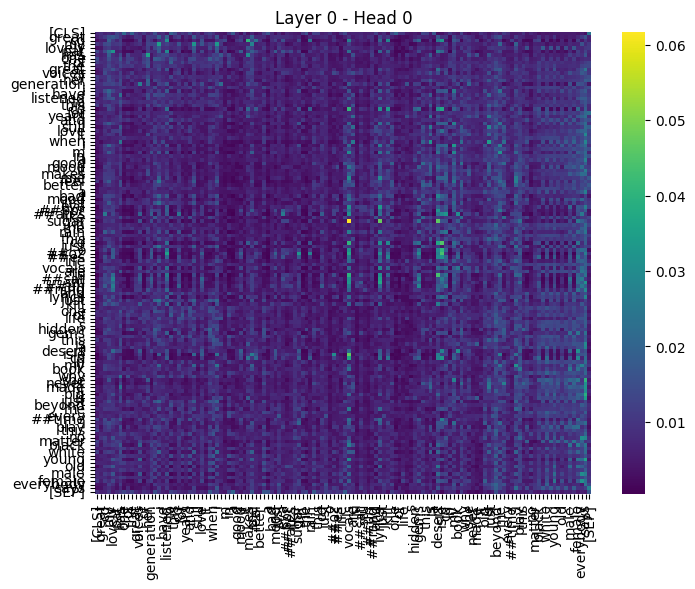

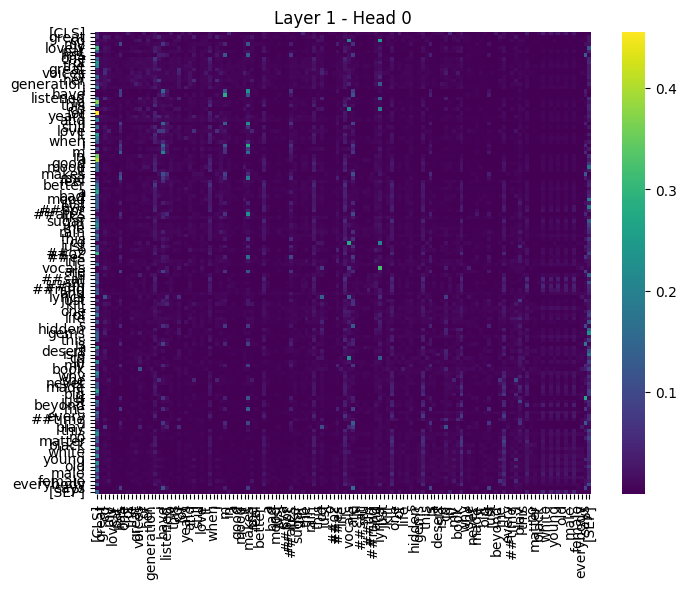

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

def plot_attention(layer, head, title):
    att = attentions[layer][0, head].cpu().numpy()

    plt.figure(figsize=(8, 6))
    sns.heatmap(att, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

plot_attention(0, 0, "Layer 0 - Head 0")
plot_attention(1, 0, "Layer 1 - Head 0")

6.3 CONFUSION MATRIX

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get predictions from trainer
pred_output = trainer.predict(final_dataset["test"].select(range(5000)))

y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[2292  143]
 [ 157 2408]]


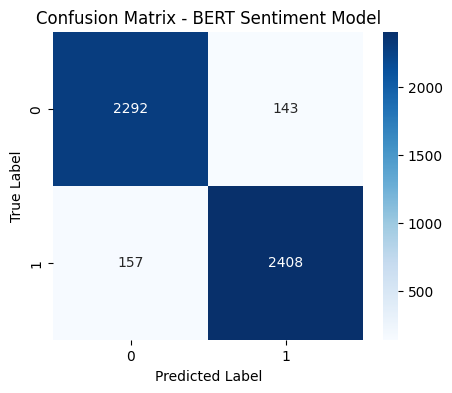

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BERT Sentiment Model")

plt.show()

# Apply XAI (LIME & Shape)

 7 **SHAPE**

7.1 Install + Setup

In [ ]:
!pip install -q shap

7.2 Prediction Function

In [ ]:
import torch
import numpy as np

def predict_proba(texts):
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    return probs.cpu().numpy()

7.3 Run SHAP

In [ ]:
import shap
import torch

# -------------------------------
# Wrapper function (VERY IMPORTANT)
# -------------------------------
class ModelWrapper:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    def __call__(self, texts):
        # Ensure texts are strings
        texts = [str(t) for t in texts]

        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        return probs.cpu().numpy()

# -------------------------------
# Initialize wrapper
# -------------------------------
wrapped_model = ModelWrapper(model, tokenizer, device)

# -------------------------------
# Use simple masker (NOT tokenizer)
# -------------------------------
# FIX: Add a text masker and use a unique name for SHAP explainer
masker = shap.maskers.Text(tokenizer, mask_token="[PAD]") # Pass the tokenizer object
shap_explainer = shap.Explainer(wrapped_model, masker=masker, output_names=["negative", "positive"])

# -------------------------------
# Get clean text
# -------------------------------
text_sample = str(dataset["test"][0]["text"])

print("Sample:\n", text_sample[:200])

# -------------------------------
# Run SHAP
# -------------------------------
shap_values = shap_explainer([text_sample])

# -------------------------------
# Plot
# -------------------------------
shap.plots.text(shap_values[0])

Sample:
 great cd my lovely pat has one of the great voices of her generation. i have listened to this cd for years and i still love it. when i'm in a good mood it makes me feel better. a bad mood just evapora


In [ ]:
import shap

shap_explanations = []

for i in range(20):
    text = tokenizer.decode(
        final_dataset["test"][i]["input_ids"],
        skip_special_tokens=True
    )

    # Use the renamed SHAP explainer
    shap_values = shap_explainer([text])
    shap_explanations.append(shap_values)

    print(f"SHAP explanation {i+1} done")

SHAP explanation 1 done
SHAP explanation 2 done
SHAP explanation 3 done
SHAP explanation 4 done
SHAP explanation 5 done
SHAP explanation 6 done
SHAP explanation 7 done
SHAP explanation 8 done
SHAP explanation 9 done
SHAP explanation 10 done
SHAP explanation 11 done
SHAP explanation 12 done
SHAP explanation 13 done
SHAP explanation 14 done
SHAP explanation 15 done
SHAP explanation 16 done
SHAP explanation 17 done
SHAP explanation 18 done
SHAP explanation 19 done
SHAP explanation 20 done


8 LIME

8.1 Setup

In [ ]:
!pip install -q lime

8.2 LIME Explainer

In [ ]:
from lime.lime_text import LimeTextExplainer

class_names = ["negative", "positive"]
lime_explainer = LimeTextExplainer(class_names=class_names)

8.3 Explain One Prediction

In [ ]:
def lime_predict(texts):
    return predict_proba(texts)

text = tokenizer.decode(final_dataset["test"][1]["input_ids"], skip_special_tokens=True)


torch.cuda.empty_cache()

exp = lime_explainer.explain_instance(
    text,
    lime_predict,
    num_features=10,
    num_samples=100
)

exp.show_in_notebook(text=True)

In [ ]:
lime_explanations = []

for i in range(20):
    text = tokenizer.decode(
        final_dataset["test"][i]["input_ids"],
        skip_special_tokens=True
    )


    torch.cuda.empty_cache()

    exp = lime_explainer.explain_instance(
        text,
        lime_predict,
        num_features=10,
        num_samples=100
    )

    lime_explanations.append(exp)

    print(f"LIME explanation {i+1} done")

LIME explanation 1 done
LIME explanation 2 done
LIME explanation 3 done
LIME explanation 4 done
LIME explanation 5 done
LIME explanation 6 done
LIME explanation 7 done
LIME explanation 8 done
LIME explanation 9 done
LIME explanation 10 done
LIME explanation 11 done
LIME explanation 12 done
LIME explanation 13 done
LIME explanation 14 done
LIME explanation 15 done
LIME explanation 16 done
LIME explanation 17 done
LIME explanation 18 done
LIME explanation 19 done
LIME explanation 20 done


8.4 comapre SHAPE AND LIME

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

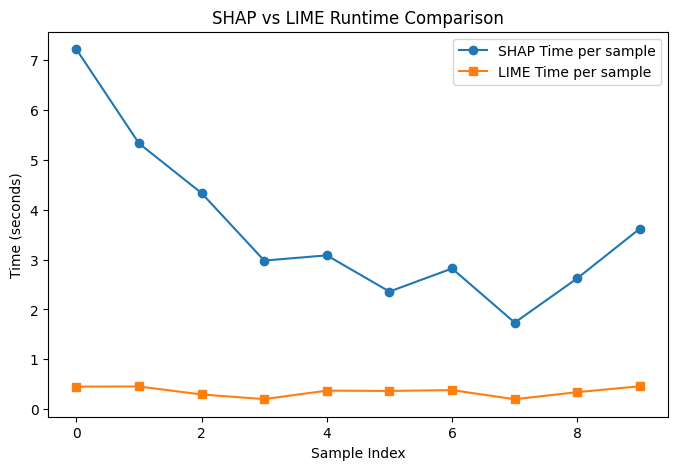

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time


n_samples = 10

shap_times = []
lime_times = []

texts = [
    tokenizer.decode(final_dataset["test"][i]["input_ids"], skip_special_tokens=True)
    for i in range(n_samples)
]

# -------------------------------
# SHAP timing
# -------------------------------
for text in texts:
    start = time.time()
    # Use the renamed SHAP explainer
    _ = shap_explainer([text])   # SHAP explanation
    shap_times.append(time.time() - start)

# -------------------------------
# LIME timing
# -------------------------------
for text in texts:
    start = time.time()
    torch.cuda.empty_cache() # Clear CUDA cache before each LIME explanation
    _ = lime_explainer.explain_instance(
        text,
        lime_predict,
        num_features=10,
        num_samples=50 # Reduced num_samples for timing comparison
    )
    lime_times.append(time.time() - start)

# -------------------------------
# Plot Line Graph
# -------------------------------
plt.figure(figsize=(8,5))

plt.plot(range(n_samples), shap_times, marker='o', label="SHAP Time per sample")
plt.plot(range(n_samples), lime_times, marker='s', label="LIME Time per sample")

plt.xlabel("Sample Index")
plt.ylabel("Time (seconds)")
plt.title("SHAP vs LIME Runtime Comparison")
plt.legend()

plt.show()

Average Runtime Bar Chart (SHAP vs LIME)

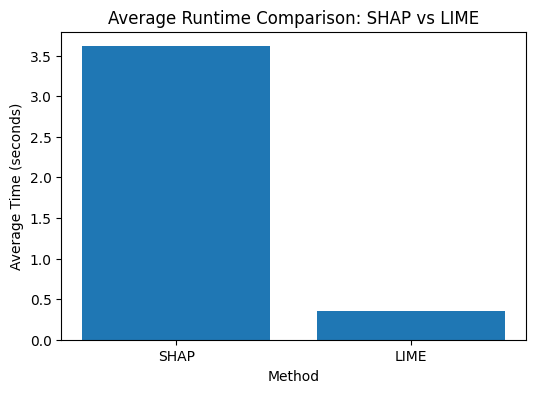

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# assume you already stored times from previous loop
avg_shap_time = np.mean(shap_times)
avg_lime_time = np.mean(lime_times)

methods = ["SHAP", "LIME"]
avg_times = [avg_shap_time, avg_lime_time]

plt.figure(figsize=(6,4))
plt.bar(methods, avg_times)

plt.xlabel("Method")
plt.ylabel("Average Time (seconds)")
plt.title("Average Runtime Comparison: SHAP vs LIME")

plt.show()

Stability Graph (Variation Across Samples)

We show how consistent each method is.

 Lower variation = more stable

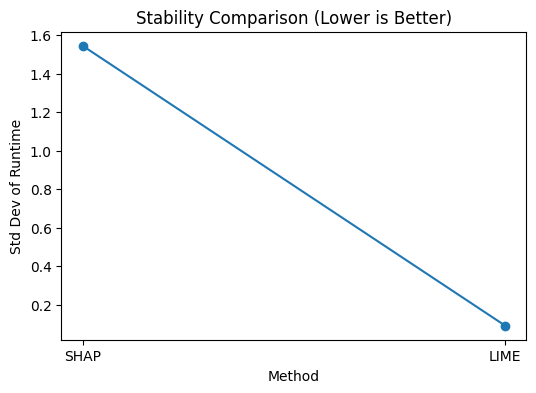

In [ ]:
shap_std = np.std(shap_times)
lime_std = np.std(lime_times)

methods = ["SHAP", "LIME"]
stability = [shap_std, lime_std]

plt.figure(figsize=(6,4))
plt.plot(methods, stability, marker='o')

plt.xlabel("Method")
plt.ylabel("Std Dev of Runtime")
plt.title("Stability Comparison (Lower is Better)")

plt.show()

Error Analysis

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# get predictions on test subset
pred_output = trainer.predict(final_dataset["test"].select(range(2000)))

y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

errors = []

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        text = tokenizer.decode(
            final_dataset["test"][i]["input_ids"],
            skip_special_tokens=True
        )
        errors.append((text, y_true[i], y_pred[i]))

# show some errors
for i, (text, true, pred) in enumerate(errors[:10]):
    print(f"\nError {i+1}")
    print("Text:", text[:200])
    print("True:", true, "Pred:", pred)


Error 1
Text: soy un apasionado del box y este libro esta esplendido! lo disfrutas, lo puedes usar como obra de consultanos trae las historia de los boxeadores mas brillantes, de los campeones durante cien anos!! s
True: 1 Pred: 0

Error 2
Text: great beginning... poor ending parricia corwell, cruel & unusual was breathtaking in the beginning! her relation to her family, her dedication to her work exeptional. however, this story began to get 
True: 1 Pred: 0

Error 3
Text: a historical gem whose title obscures its intent started laughing in the second chapter.... enjoyed the book after i realized that i wasn ' t going to learn anything new. it ' s obviously a miracle th
True: 0 Pred: 1

Error 4
Text: had to return it the sizing is perfect and a medium fits just right. i am 5 ' 2 size 4 137 lbs before baby and i gained about 35 lbs during pregnancy, just an idea for sizing but keepin mind that ever
True: 0 Pred: 1

Error 5
Text: i recommend ordering a size or 2 larger than your regular

In [ ]:
# =========================================
# COLAB UI (No Streamlit, runs inside notebook)
# =========================================

import ipywidgets as widgets
from IPython.display import display
import torch

# Input box
text_input = widgets.Textarea(
    value='',
    placeholder='Enter your review here...',
    description='Review:',
    layout=widgets.Layout(width='600px', height='100px')
)

# Button
button = widgets.Button(description="Predict")

# Output
output = widgets.Output()

def predict_sentiment(b):
    with output:
        output.clear_output()

        text = text_input.value

        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

        label = "Positive 😊" if pred == 1 else "Negative 😞"

        print("Prediction:", label)
        print("Confidence:", probs.cpu().numpy())

button.on_click(predict_sentiment)

display(text_input, button, output)

Textarea(value='', description='Review:', layout=Layout(height='100px', width='600px'), placeholder='Enter you…

Button(description='Predict', style=ButtonStyle())

Output()